# 01 – Handling Missing Values
Load the raw Beijing housing transactions, drop identifier columns, and handle missing values.

**Output:** `data/processed/housing_no_missing.csv`

## Load data
The file contains Chinese characters, so it is read with the `gbk` encoding. The first column is a leftover index and is dropped on load.

In [1]:
import pandas as pd
housing = pd.read_csv('../data/raw/housing_data.csv.gz', encoding='gbk', low_memory=False)
housing.drop(columns=['Unnamed: 0'], inplace=True)
housing.head()

,url,id,Lng,Lat,Cid,tradeTime,DOM,totalPrice,square,livingRoom,...,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,https://bj.lianjia.com/chengjiao/101084782030....,101084782030,116.475489,40.019520,1111027376244,2016-08-09,1464.0,415.0,131.00,2,...,1,1,高 26,2005,3,6,0.217,1.0,1.0,7
1,https://bj.lianjia.com/chengjiao/101086012217....,101086012217,116.453917,39.881534,1111027381879,2016-07-28,903.0,575.0,132.38,2,...,1,2,高 22,2004,4,6,0.667,1.0,0.0,7
2,https://bj.lianjia.com/chengjiao/101086041636....,101086041636,116.561978,39.877145,1111040862969,2016-12-11,1271.0,1030.0,198.00,3,...,1,3,中 4,2005,3,6,0.500,1.0,0.0,7
3,https://bj.lianjia.com/chengjiao/101086406841....,101086406841,116.438010,40.076114,1111043185817,2016-09-30,965.0,297.5,134.00,3,...,1,1,底 21,2008,1,6,0.273,1.0,0.0,6
4,https://bj.lianjia.com/chengjiao/101086920653....,101086920653,116.428392,39.886229,1111027381174,2016-08-28,927.0,392.0,81.00,2,...,1,1,中 6,1960,2,2,0.333,0.0,1.0,1


## Data dictionary
| Column | Description |
|---|---|
| `Lng`, `Lat` | Longitude / latitude of the property |
| `tradeTime` | Transaction date |
| `DOM` | Days on market (time since the listing was posted) |
| `totalPrice` | Sale price |
| `square` | Floor area |
| `livingRoom`, `drawingRoom`, `kitchen`, `bathRoom` | Room counts |
| `floor` | Floor height category (Chinese label) and floor number |
| `constructionTime` | Year built |
| `renovationCondition`, `buildingStructure` | Coded renovation status / building structure |
| `elevator`, `subway` | Binary flags: has elevator / near subway |
| `district` | District code |
| `url`, `id`, `Cid`, `ladderRatio` | Identifiers and a ratio column (not used in the analysis) |

In [2]:
housing.shape

(318851, 21)

## Drop identifier columns
`url`, `id` and `Cid` are identifiers with no analytical value.

In [3]:
housing_dropped = housing.drop(columns=['Cid','id','url'])
housing_dropped.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,高 26,2005,3,6,0.217,1.0,1.0,7
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,高 22,2004,4,6,0.667,1.0,0.0,7
2,116.561978,39.877145,2016-12-11,1271.0,1030.0,198.00,3,2,1,3,中 4,2005,3,6,0.500,1.0,0.0,7
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,底 21,2008,1,6,0.273,1.0,0.0,6
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,中 6,1960,2,2,0.333,0.0,1.0,1


## Missing values per column

In [4]:
housing_null = housing_dropped.isna().sum().to_frame()
housing_null

,0
Lng,0
Lat,0
tradeTime,0
DOM,157977
totalPrice,0
square,0
livingRoom,0
drawingRoom,0
kitchen,0
bathRoom,0


## Choose an imputation strategy for `DOM`
`DOM` is missing for about half of the rows, so dropping them would discard too much data, and the feature is informative. Its distribution contains many extreme values (box plot below), so the mean is a poor fill value; the **mode** is used instead.

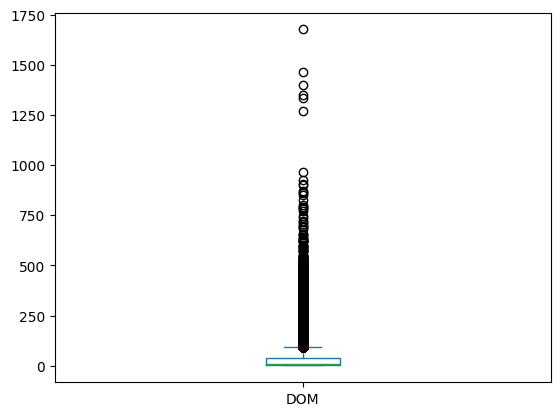

In [5]:
housing_dropped.DOM.plot(kind = 'box');

## Impute and clean
Fill `DOM` with its mode, then drop the few rows where `elevator` or `subway` is missing. Work on a copy so the original frame stays unchanged.

In [6]:
housing_no_missing = housing_dropped.copy()

housing_no_missing['DOM'] = housing_no_missing['DOM'].fillna(
    housing_no_missing['DOM'].mode()[0]
)

housing_no_missing = housing_no_missing.dropna(
    subset=['elevator', 'subway']
)

In [7]:
housing_no_missing.info()

<class 'pandas.DataFrame'>
Index: 318819 entries, 0 to 318850
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Lng                  318819 non-null  float64
 1   Lat                  318819 non-null  float64
 2   tradeTime            318819 non-null  str    
 3   DOM                  318819 non-null  float64
 4   totalPrice           318819 non-null  float64
 5   square               318819 non-null  float64
 6   livingRoom           318819 non-null  str    
 7   drawingRoom          318819 non-null  str    
 8   kitchen              318819 non-null  int64  
 9   bathRoom             318819 non-null  str    
 10  floor                318819 non-null  str    
 11  constructionTime     318819 non-null  str    
 12  renovationCondition  318819 non-null  int64  
 13  buildingStructure    318819 non-null  int64  
 14  ladderRatio          318819 non-null  float64
 15  elevator             318819 non-n

## Save
Written with `gbk` encoding to preserve the Chinese characters.

In [8]:
from pathlib import Path

Path('../data/processed').mkdir(parents=True, exist_ok=True)
housing_no_missing.to_csv('../data/processed/housing_no_missing.csv', encoding='gbk', index=False)